In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

# Enhanced Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.6)
sns.set_palette("deep")

# Configure matplotlib for publication quality with BOLD and BIGGER fonts
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['legend.title_fontsize'] = 13
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print("✅ Libraries loaded successfully!")
print("✅ Enhanced academic publication style configured")
print("📊 Experiment 2: WITH Artist Features (414 features)")

✅ Libraries loaded successfully!
✅ Enhanced academic publication style configured
📊 Experiment 2: WITH Artist Features (414 features)


In [2]:
# Load Experiment 2 results (with artist features)
df_raw = pd.read_csv('../results/metrics/experiment2_with_artist/enhanced_results_detailed_20251231_143812.csv')

# Filter to keep only specified models
selected_models = [
    'CatBoost', 'CatBoost_tuned',
    'LightGBM', 'LightGBM_tuned',
    'XGBoost', 'XGBoost_tuned',
    'ExtraTrees', 'ExtraTrees_tuned',
    'MLPRegressor', 'MLPRegressor_tuned',
    'RandomForest', 'RandomForest_tuned'
]

df = df_raw[df_raw['model'].isin(selected_models)].copy()

print(f"📁 Loaded {len(df_raw)} total model results from Experiment 2")
print(f"✂️  Filtered to {len(df)} results ({len(selected_models)} models)")
print(f"📊 Targets: {df['target'].unique().tolist()}")
print(f"🤖 Selected Models: {sorted(df['model'].unique().tolist())}")
print(f"🎯 Features: 414 (23 audio + 5 text + 2 sentiment + 384 embeddings)")
print(f"➕ Artist Features: log_total_artist_followers + avg_artist_popularity")

📁 Loaded 100 total model results from Experiment 2
✂️  Filtered to 48 results (12 models)
📊 Targets: ['valence', 'energy', 'danceability', 'popularity']
🤖 Selected Models: ['CatBoost', 'CatBoost_tuned', 'ExtraTrees', 'ExtraTrees_tuned', 'LightGBM', 'LightGBM_tuned', 'MLPRegressor', 'MLPRegressor_tuned', 'RandomForest', 'RandomForest_tuned', 'XGBoost', 'XGBoost_tuned']
🎯 Features: 414 (23 audio + 5 text + 2 sentiment + 384 embeddings)
➕ Artist Features: log_total_artist_followers + avg_artist_popularity


---
## 🏆 Best Models Summary (Quick Overview)

In [3]:
# Find best model for each target
best_models = df.loc[df.groupby('target')['r2'].idxmax()][['target', 'model', 'r2', 'rmse', 'mae']]
best_models = best_models.sort_values('r2', ascending=False)

styled_best = best_models.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}'
}).set_caption('🏆 Best Model Per Target').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]}
])

display(styled_best)

,target,model,r2,rmse,mae
39,energy,XGBoost_tuned,0.8475,0.0979,0.0733
65,danceability,CatBoost,0.5948,0.1101,0.0870
14,valence,XGBoost_tuned,0.4169,0.1894,0.1521
91,popularity,CatBoost_tuned,0.1405,1.3669,1.1679


---
## 🎭 Valence Models (Emotional Positivity)

In [4]:
def create_styled_table(df, target, sort_by='r2', ascending=False):
    """Create a beautifully styled table for a specific target, separated by default and tuned"""
    target_df = df[df['target'] == target].copy()
    target_df = target_df.sort_values(sort_by, ascending=ascending)
    
    # Select key columns
    cols = ['model', 'r2', 'rmse', 'mae', 'explained_variance', 'train_time_seconds']
    target_df = target_df[cols].reset_index(drop=True)
    
    # Split into default and tuned
    default_df = target_df[~target_df['model'].str.contains('_tuned')].copy()
    tuned_df = target_df[target_df['model'].str.contains('_tuned')].copy()
    
    # Add ranks
    default_df['rank'] = range(1, len(default_df) + 1)
    tuned_df['rank'] = range(1, len(tuned_df) + 1)
    
    default_df = default_df[['rank'] + cols]
    tuned_df = tuned_df[['rank'] + cols]
    
    # Display both tables
    print(f"\n{'='*80}")
    print(f"{target.upper()} - DEFAULT MODELS")
    print('='*80)
    
    styled_default = default_df.style.format({
        'r2': '{:.4f}',
        'rmse': '{:.4f}',
        'mae': '{:.4f}',
        'explained_variance': '{:.4f}',
        'train_time_seconds': '{:.1f}s'
    }).set_caption(
        f'📊 {target.upper()} - Default Models (Sorted by R²)'
    ).set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2E86AB')]},
        {'selector': 'th', 'props': [('background-color', '#4A90D9'), ('color', 'white')]},
    ])
    display(styled_default)
    
    print(f"\n{'='*80}")
    print(f"{target.upper()} - TUNED MODELS")
    print('='*80)
    
    styled_tuned = tuned_df.style.format({
        'r2': '{:.4f}',
        'rmse': '{:.4f}',
        'mae': '{:.4f}',
        'explained_variance': '{:.4f}',
        'train_time_seconds': '{:.1f}s'
    }).set_caption(
        f'🔧 {target.upper()} - Tuned Models (Sorted by R²)'
    ).set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#F18F01')]},
        {'selector': 'th', 'props': [('background-color', '#F18F01'), ('color', 'white')]},
    ])
    display(styled_tuned)

create_styled_table(df, 'valence')


VALENCE - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
2,1,CatBoost,0.4132,0.1900,0.1527,0.4145,158.2s
4,2,MLPRegressor,0.3952,0.1929,0.1546,0.3955,282.3s
6,3,LightGBM,0.3859,0.1943,0.1570,0.3870,22.2s
7,4,XGBoost,0.3802,0.1952,0.1568,0.3813,71.9s
8,5,ExtraTrees,0.3679,0.1972,0.1611,0.3686,961.6s
9,6,RandomForest,0.3599,0.1984,0.1613,0.3608,4581.5s



VALENCE - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.4169,0.1894,0.1521,0.4183,709.6s
1,2,CatBoost_tuned,0.4149,0.1897,0.1522,0.4161,668.9s
3,3,LightGBM_tuned,0.4123,0.1901,0.1529,0.4135,81.8s
5,4,MLPRegressor_tuned,0.3940,0.1931,0.1548,0.3940,149.7s
10,5,ExtraTrees_tuned,0.3564,0.1990,0.1632,0.3571,406.3s
11,6,RandomForest_tuned,0.2704,0.2118,0.1766,0.2713,168.1s


---
## ⚡ Energy Models (Intensity)

In [5]:
display(create_styled_table(df, 'energy'))


ENERGY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
2,1,CatBoost,0.8472,0.0980,0.0735,0.8472,204.8s
4,2,LightGBM,0.8406,0.1001,0.0752,0.8406,27.7s
5,3,XGBoost,0.8400,0.1003,0.0753,0.8400,84.5s
6,4,MLPRegressor,0.8369,0.1013,0.0759,0.8370,1696.2s
8,5,ExtraTrees,0.8313,0.1030,0.0777,0.8313,983.5s
9,6,RandomForest,0.8292,0.1037,0.0781,0.8292,4760.0s



ENERGY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.8475,0.0979,0.0733,0.8475,401.7s
1,2,CatBoost_tuned,0.8473,0.0980,0.0733,0.8473,809.8s
3,3,LightGBM_tuned,0.8459,0.0985,0.0739,0.8459,47.5s
7,4,MLPRegressor_tuned,0.8349,0.1019,0.0770,0.8350,726.6s
10,5,ExtraTrees_tuned,0.8280,0.1040,0.0786,0.8280,433.8s
11,6,RandomForest_tuned,0.7197,0.1328,0.1079,0.7207,176.8s


None

---
## 💃 Danceability Models

In [6]:
display(create_styled_table(df, 'danceability'))


DANCEABILITY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,CatBoost,0.5948,0.1101,0.0870,0.5953,189.7s
5,2,MLPRegressor,0.5697,0.1134,0.0894,0.5702,1199.3s
6,3,XGBoost,0.5689,0.1135,0.0897,0.5694,97.3s
7,4,LightGBM,0.5657,0.1140,0.0904,0.5663,28.3s
8,5,ExtraTrees,0.5544,0.1154,0.0918,0.5553,1014.0s
9,6,RandomForest,0.5490,0.1161,0.0923,0.5501,4616.3s



DANCEABILITY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
1,1,XGBoost_tuned,0.5933,0.1103,0.0872,0.5939,562.7s
2,2,LightGBM_tuned,0.5932,0.1103,0.0870,0.5937,74.9s
3,3,CatBoost_tuned,0.5920,0.1105,0.0873,0.5925,850.3s
4,4,MLPRegressor_tuned,0.5715,0.1132,0.0893,0.5719,290.5s
10,5,ExtraTrees_tuned,0.5442,0.1168,0.0930,0.5447,611.1s
11,6,RandomForest_tuned,0.4450,0.1288,0.1038,0.4459,204.4s


None

---
## 🌟 Popularity Models (Hardest Target)

In [7]:
display(create_styled_table(df, 'popularity'))


POPULARITY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
1,1,CatBoost,0.1394,1.3678,1.1656,0.1395,167.1s
3,2,LightGBM,0.1364,1.3701,1.1730,0.1366,21.3s
6,3,MLPRegressor,0.1209,1.3823,1.1684,0.1209,61.1s
7,4,RandomForest,0.1183,1.3845,1.1759,0.1183,6718.0s
8,5,ExtraTrees,0.1177,1.3849,1.1742,0.1179,1227.6s
9,6,XGBoost,0.1167,1.3857,1.1757,0.1168,84.2s



POPULARITY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,CatBoost_tuned,0.1405,1.3669,1.1679,0.1406,385.6s
2,2,LightGBM_tuned,0.1378,1.3690,1.1696,0.1379,40.4s
4,3,XGBoost_tuned,0.1329,1.3729,1.1724,0.1329,226.1s
5,4,ExtraTrees_tuned,0.1253,1.3789,1.1829,0.1254,650.4s
10,5,MLPRegressor_tuned,0.1159,1.3863,1.1793,0.1163,134.6s
11,6,RandomForest_tuned,0.0958,1.4020,1.2263,0.0959,221.5s


None

---
## 📈 Visual Comparison: R² Scores Across All Targets

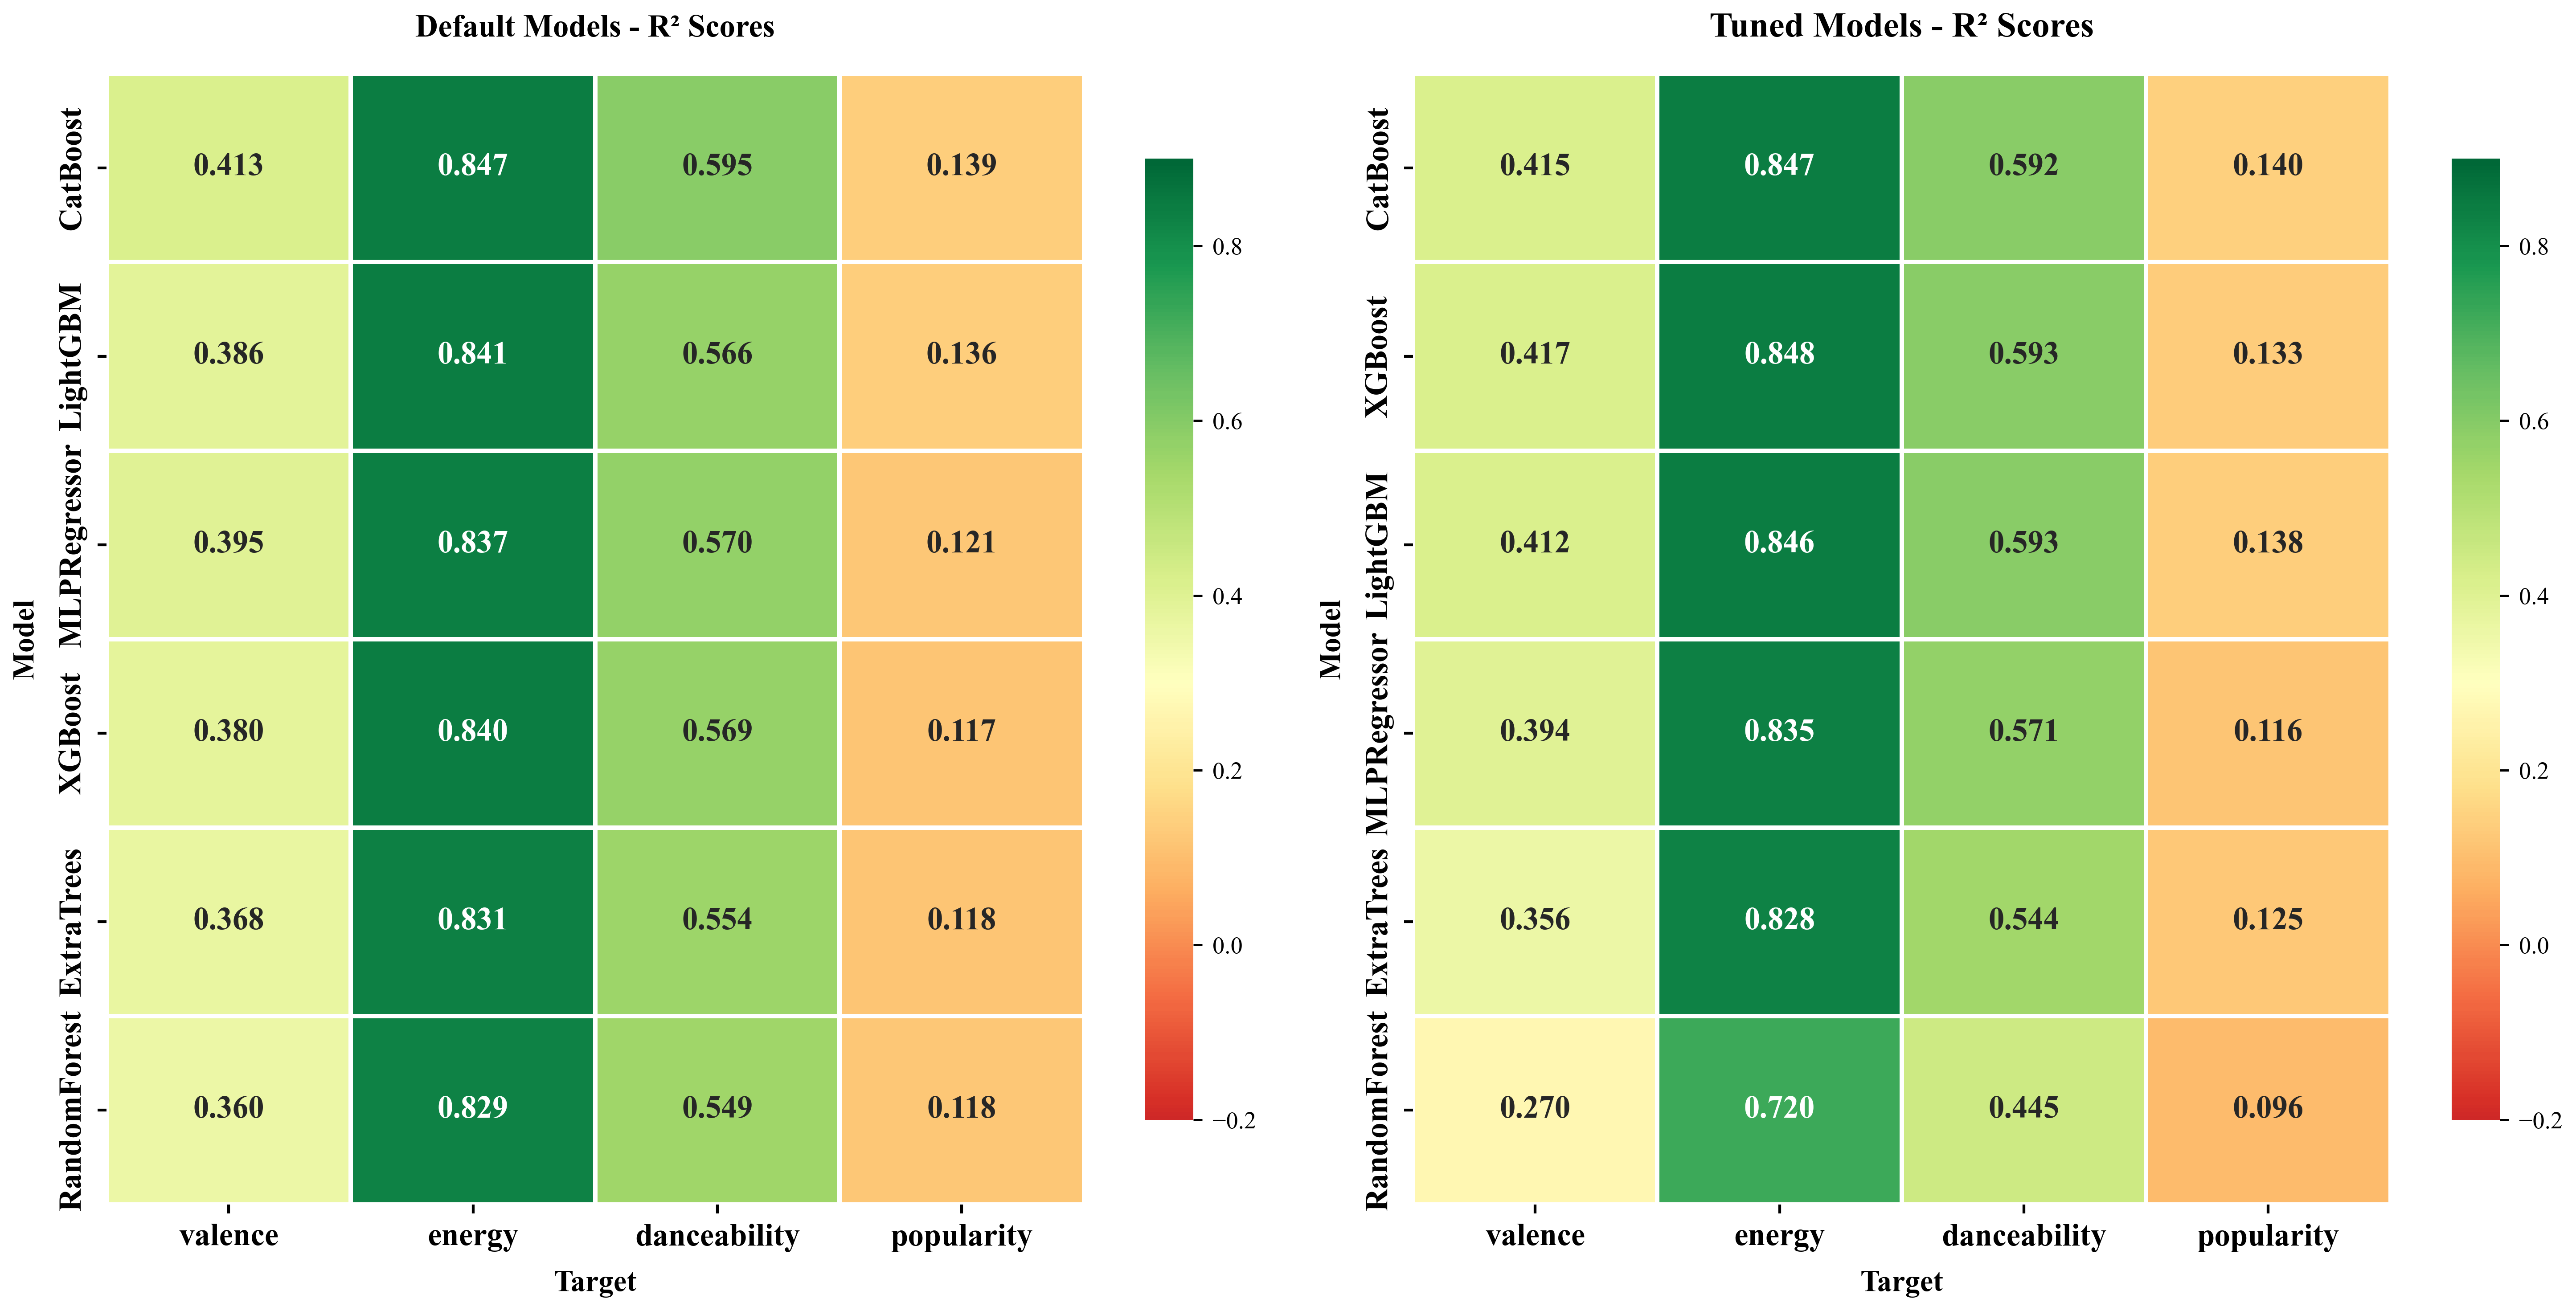

💾 Saved: results/figures/experiment2_r2_heatmap_comparison.png


In [19]:
# Create separate R² comparison heatmaps for default and tuned models - Enhanced styling
df_default = df[~df['model'].str.contains('_tuned')].copy()
df_tuned = df[df['model'].str.contains('_tuned')].copy()

# Clean model names for tuned (remove _tuned suffix)
df_tuned['model_clean'] = df_tuned['model'].str.replace('_tuned', '')

# Create pivots
pivot_default = df_default.pivot(index='model', columns='target', values='r2')
pivot_tuned = df_tuned.pivot(index='model_clean', columns='target', values='r2')

# Order columns
target_order = ['valence', 'energy', 'danceability', 'popularity']
pivot_default = pivot_default[target_order]
pivot_tuned = pivot_tuned[target_order]

# Sort by average R²
pivot_default['avg_r2'] = pivot_default.mean(axis=1)
pivot_default = pivot_default.sort_values('avg_r2', ascending=False).drop('avg_r2', axis=1)

pivot_tuned['avg_r2'] = pivot_tuned.mean(axis=1)
pivot_tuned = pivot_tuned.sort_values('avg_r2', ascending=False).drop('avg_r2', axis=1)

# Create side-by-side heatmaps with enhanced styling
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Default models

sns.heatmap(pivot_default, annot=True, fmt='.3f', cmap='RdYlGn', center=0.3,
            linewidths=2, linecolor='white', ax=axes[0], vmin=-0.2, vmax=0.9,
            cbar_kws={'shrink': 0.85},
            annot_kws={'fontsize': 17, 'weight': 'bold'})
axes[0].set_title('Default Models - R² Scores', fontsize=17, fontweight='bold', pad=20)
axes[0].set_xlabel('Target', fontsize=16, fontweight='bold', labelpad=10)
axes[0].set_ylabel('Model', fontsize=16, fontweight='bold', labelpad=10)
axes[0].tick_params(axis='x', labelsize=17, width=1.5)
axes[0].tick_params(axis='y', labelsize=17, width=1.5)
plt.setp(axes[0].get_xticklabels(), fontweight='bold')
plt.setp(axes[0].get_yticklabels(), fontweight='bold')

# Tuned models
sns.heatmap(pivot_tuned, annot=True, fmt='.3f', cmap='RdYlGn', center=0.3,
            linewidths=2, linecolor='white', ax=axes[1], vmin=-0.2, vmax=0.9,
            cbar_kws={'shrink': 0.85},
            annot_kws={'fontsize': 17, 'weight': 'bold'})
axes[1].set_title('Tuned Models - R² Scores', fontsize=19, fontweight='bold', pad=20)
axes[1].set_xlabel('Target', fontsize=16, fontweight='bold', labelpad=10)
axes[1].set_ylabel('Model', fontsize=16, fontweight='bold', labelpad=10)
axes[1].tick_params(axis='x', labelsize=17, width=1.5)
axes[1].tick_params(axis='y', labelsize=17, width=1.5)
plt.setp(axes[1].get_xticklabels(), fontweight='bold')
plt.setp(axes[1].get_yticklabels(), fontweight='bold')

# plt.suptitle('R² Scores Comparison', 
#              fontsize=19, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_r2_heatmap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_r2_heatmap_comparison.png")

---
## 📊 Top 5 Models Bar Chart Per Target

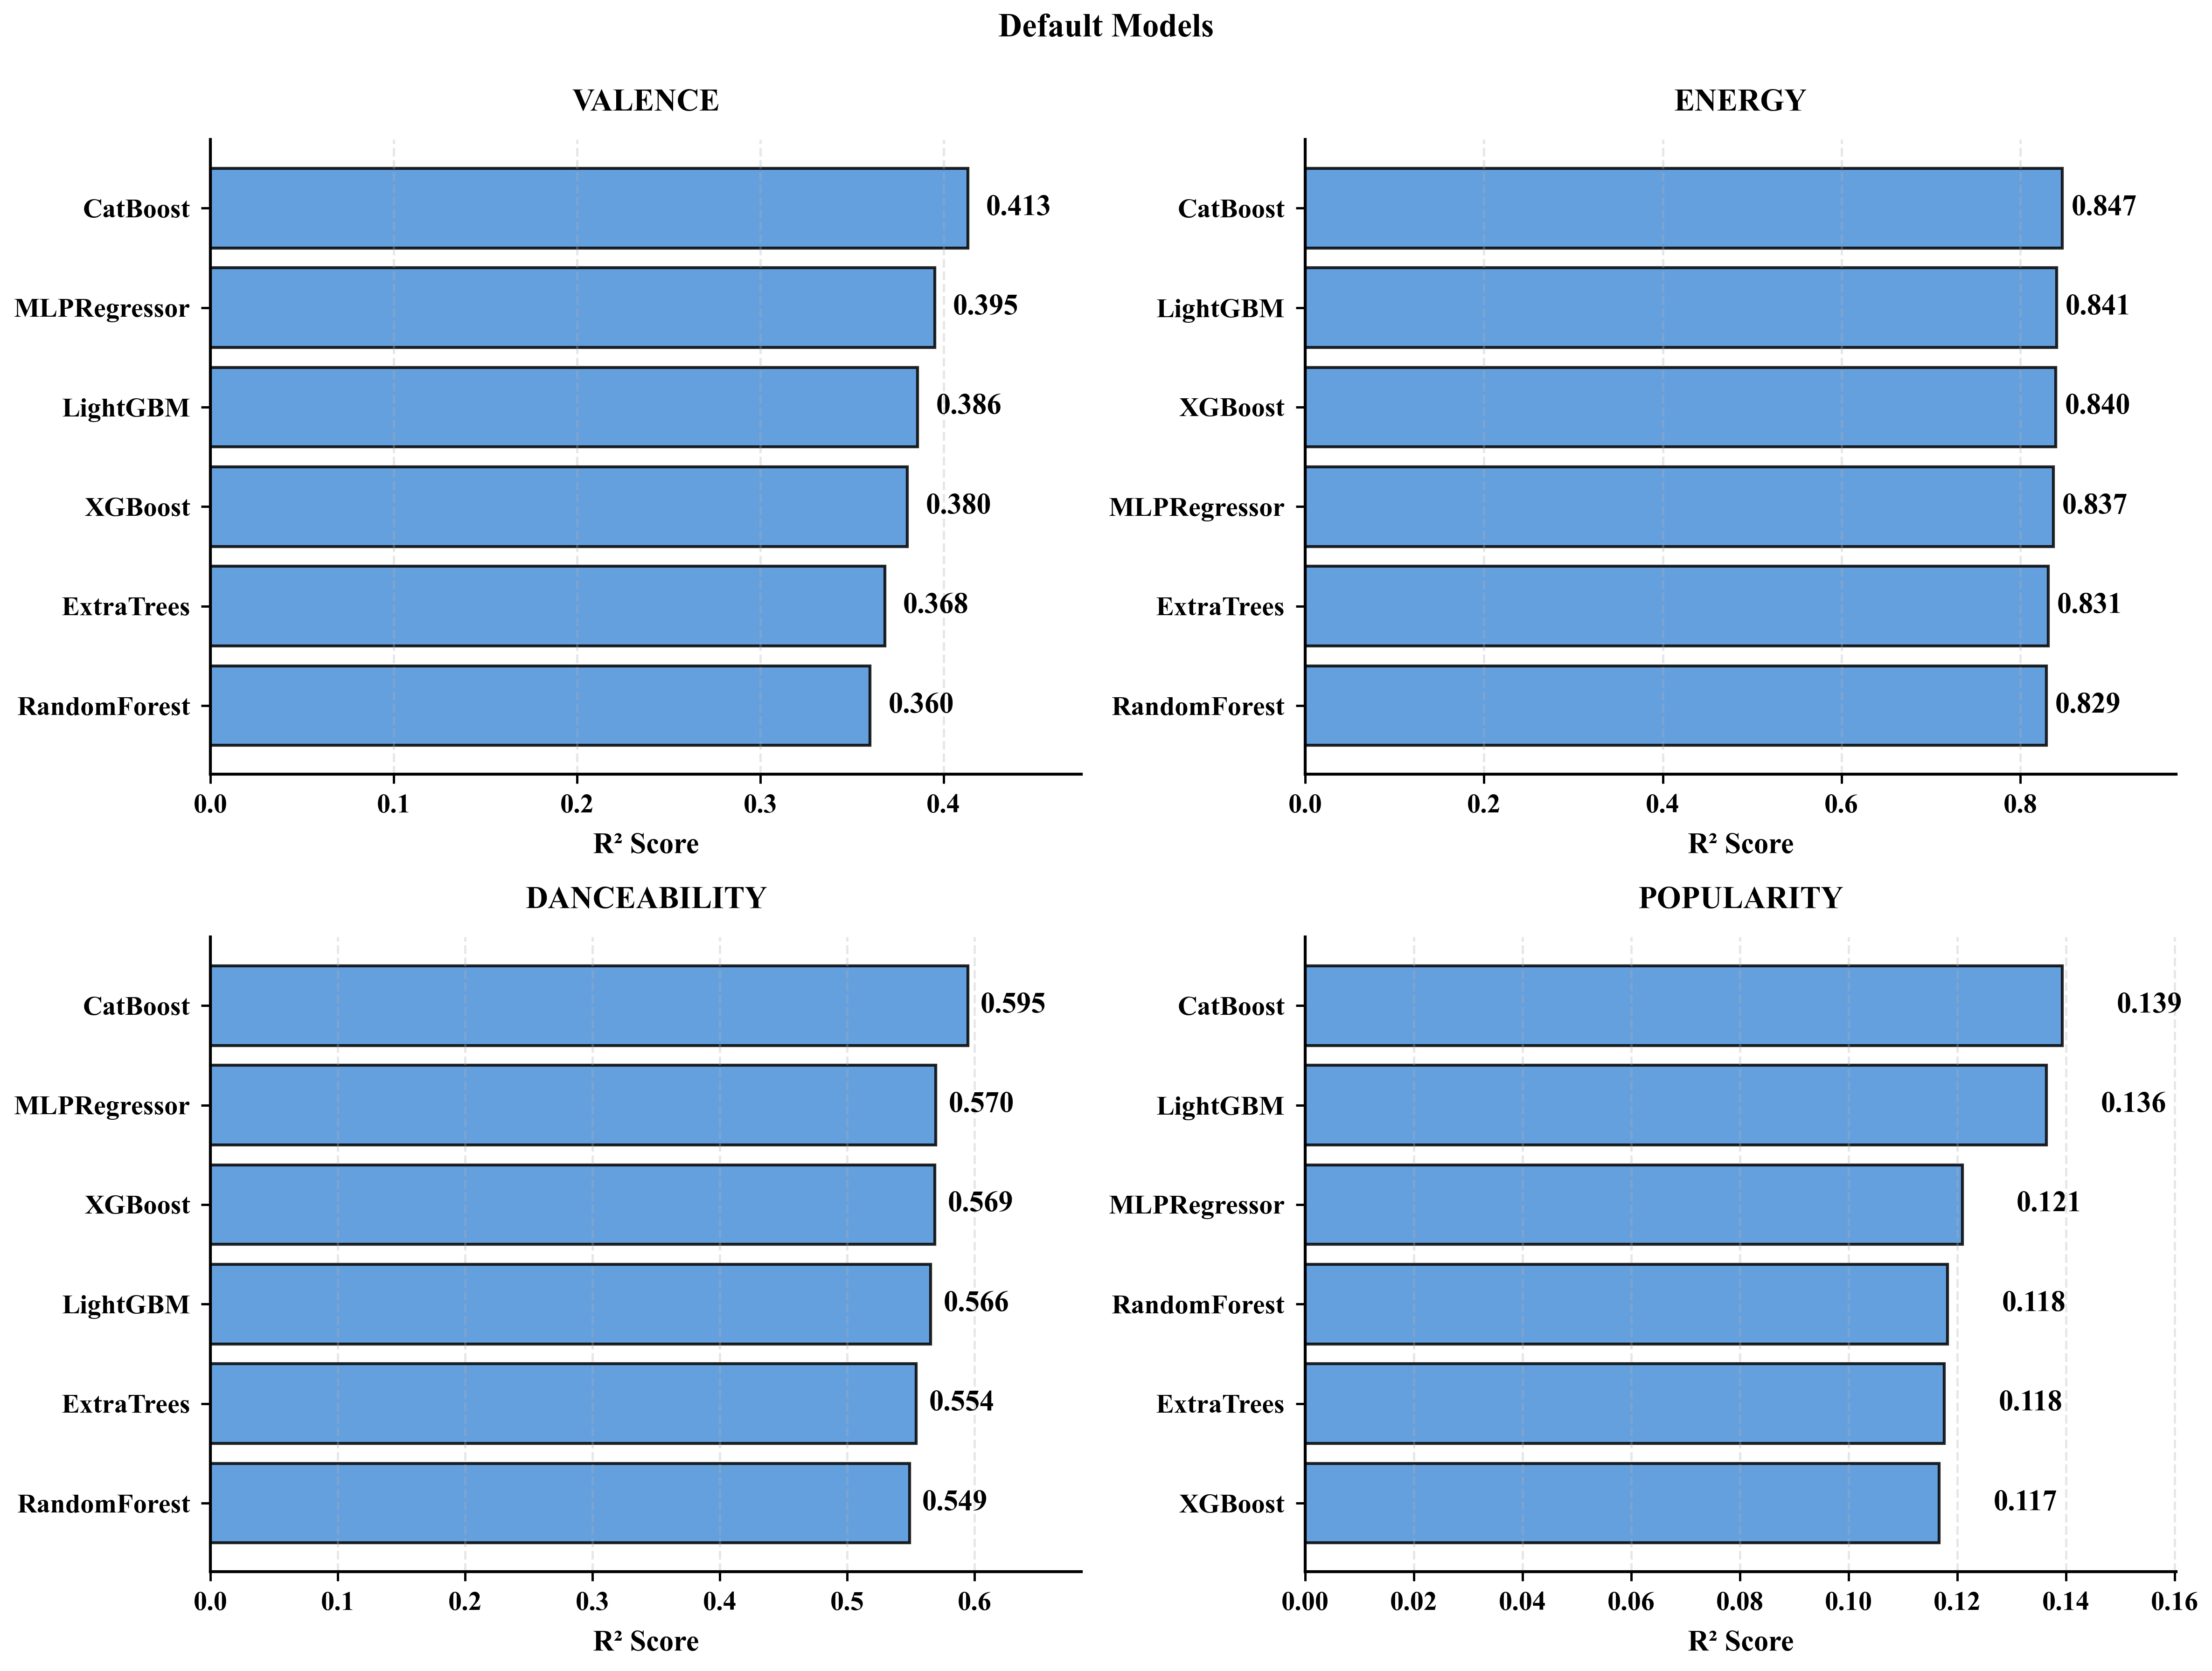

💾 Saved: results/figures/experiment2_default_models.png


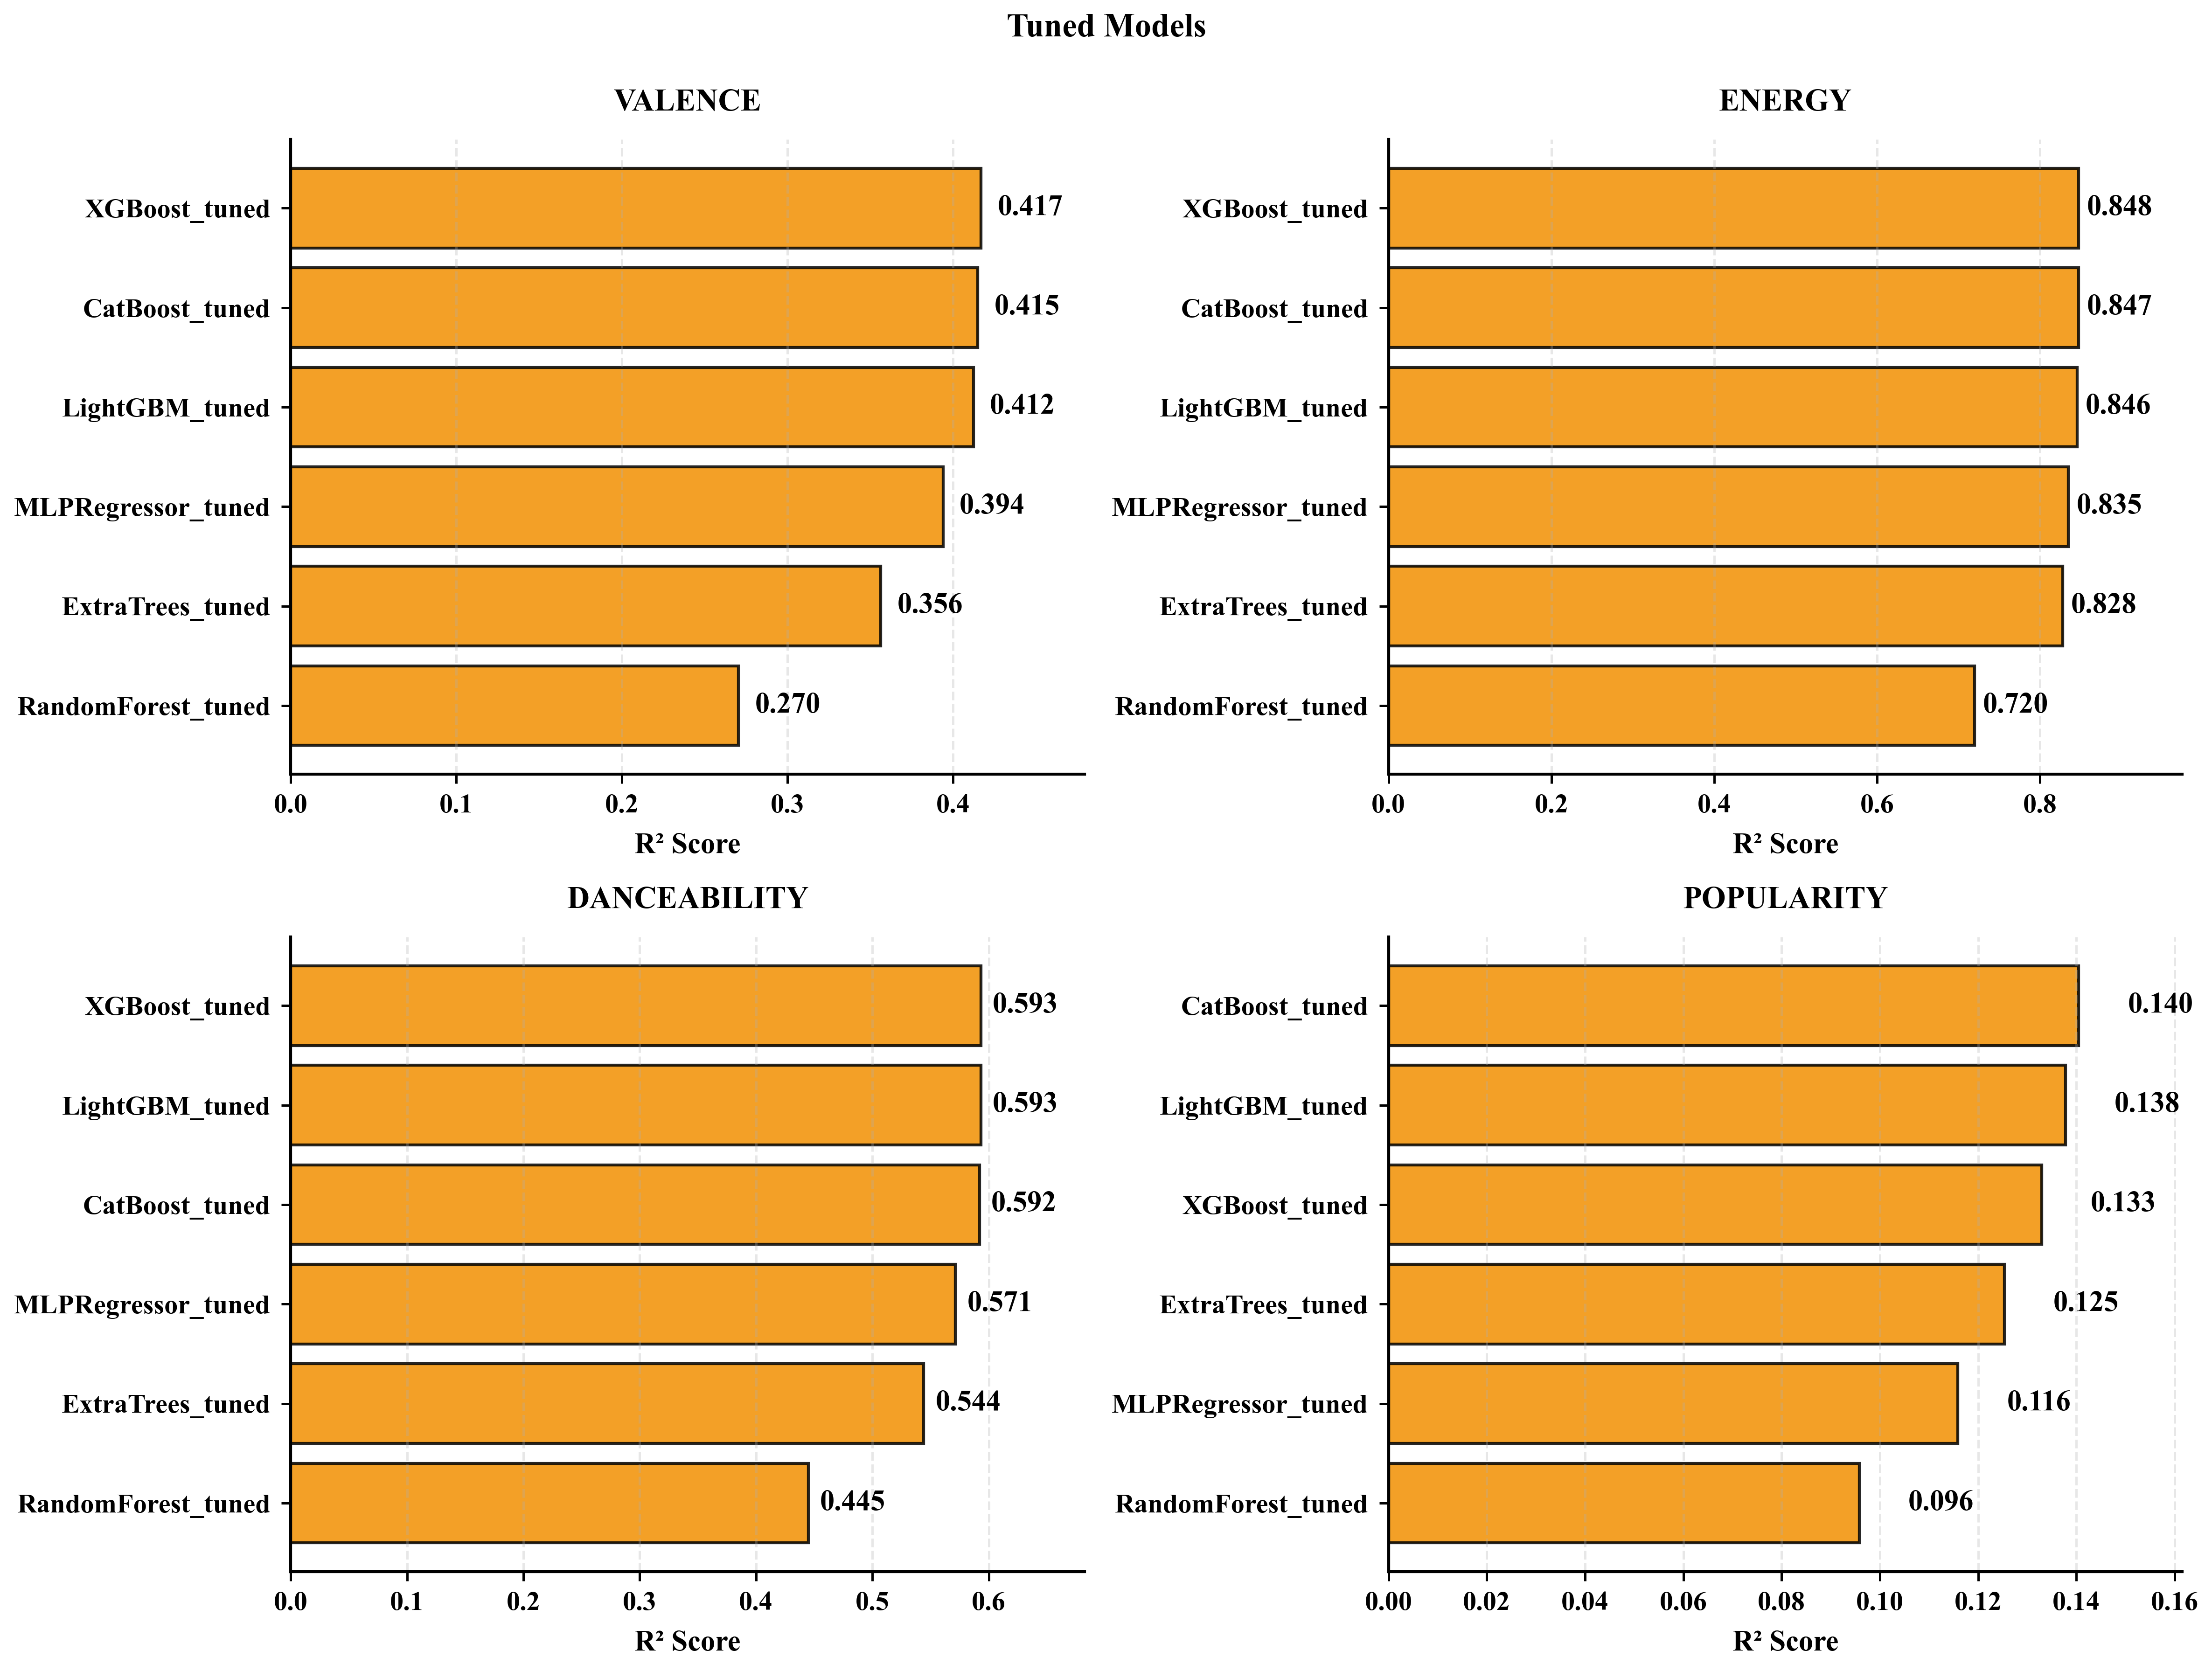

💾 Saved: results/figures/experiment2_tuned_models.png


In [21]:
# Create separate bar charts for default and tuned models - Enhanced styling
targets = ['valence', 'energy', 'danceability', 'popularity']

# Default models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_default[df_default['target'] == target].nlargest(6, 'r2')
    
    bars = ax.barh(top_models['model'], top_models['r2'], color='#4A90D9', 
                   edgecolor='black', alpha=0.85, linewidth=1.5)
    ax.set_xlabel('R² Score', fontsize=15, fontweight='bold', labelpad=8)
    ax.set_title(f'{target.upper()}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim(0, max(top_models['r2']) * 1.15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', width=1.2, labelsize=12)
    
    # Add value labels
    for bar, val in zip(bars, top_models['r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=15, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=14)

plt.suptitle('Default Models', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_default_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_default_models.png")

# Tuned models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_tuned[df_tuned['target'] == target].nlargest(6, 'r2')
    
    bars = ax.barh(top_models['model'], top_models['r2'], color='#F18F01', 
                   edgecolor='black', alpha=0.85, linewidth=1.5)
    ax.set_xlabel('R² Score', fontsize=15, fontweight='bold', labelpad=8)
    ax.set_title(f'{target.upper()}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim(0, max(top_models['r2']) * 1.15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', width=1.2, labelsize=14)
    
    # Add value labels
    for bar, val in zip(bars, top_models['r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=15, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=14)

plt.suptitle('Tuned Models', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_tuned_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_tuned_models.png")

---
## ⏱️ Training Time Analysis

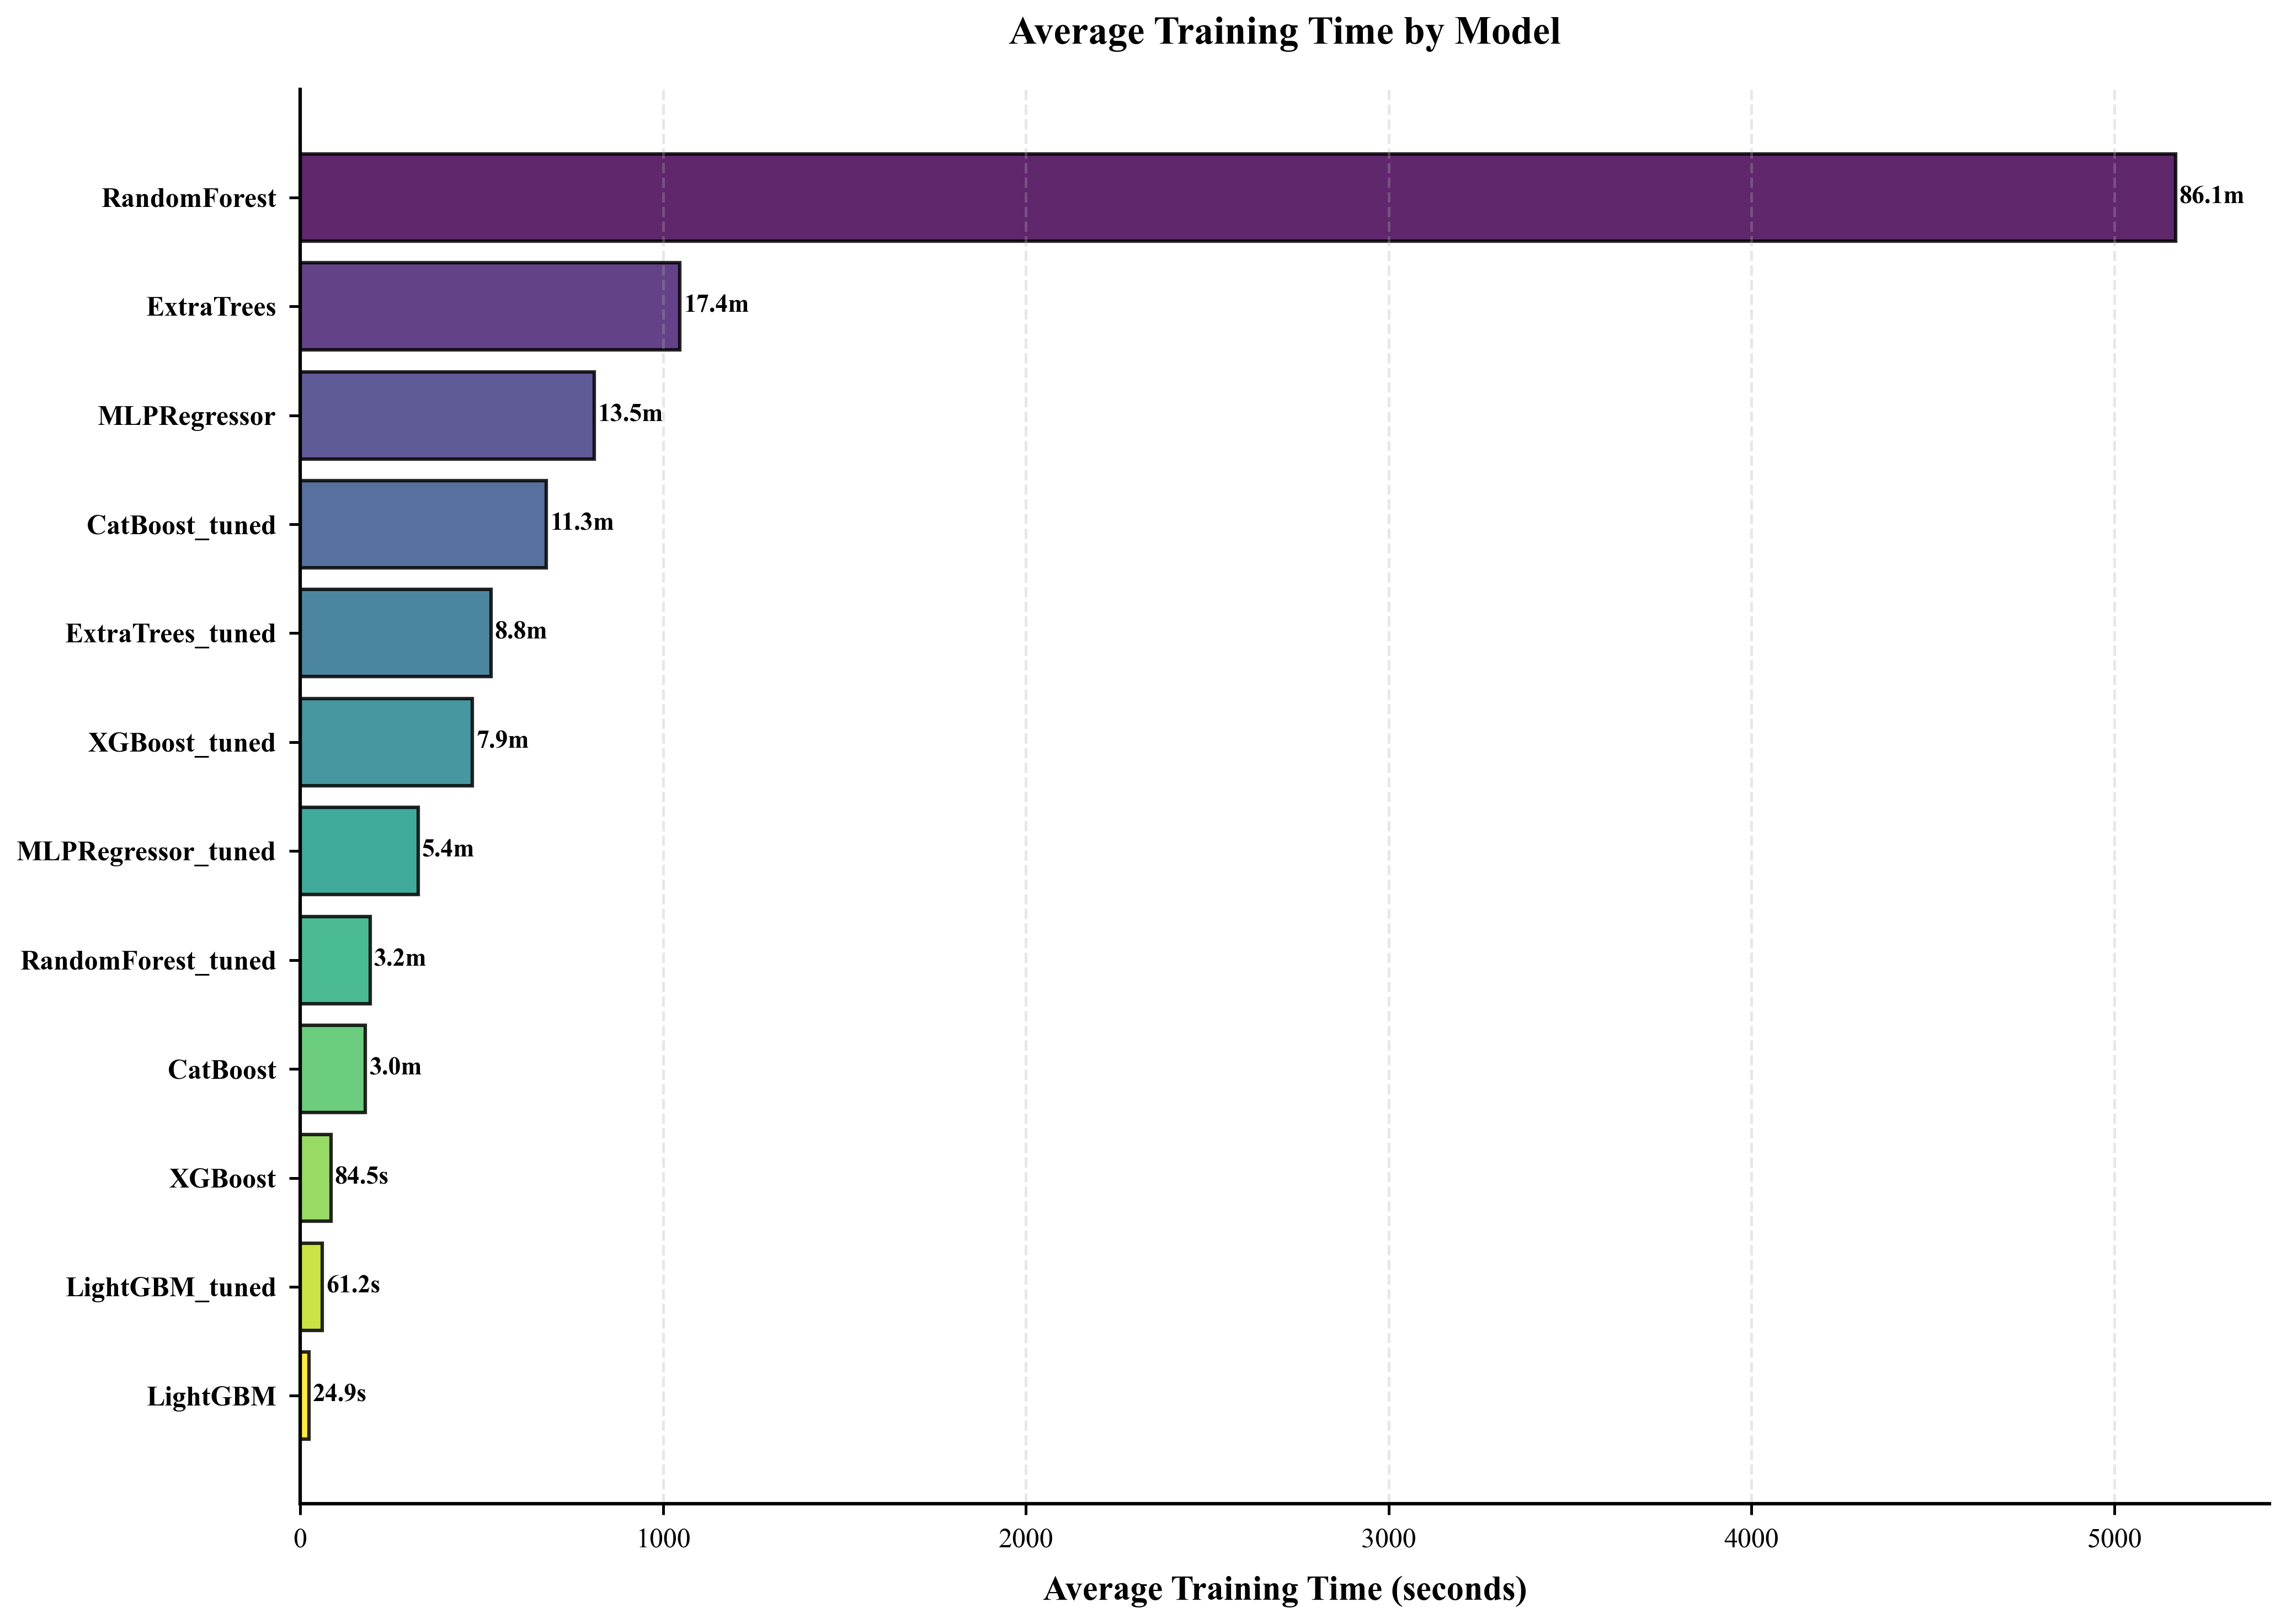

💾 Saved: results/figures/experiment2_training_time_selected.png


In [10]:
# Aggregate training time by model - Enhanced styling
time_by_model = df.groupby('model')['train_time_seconds'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_by_model)))
bars = ax.barh(time_by_model.index, time_by_model.values, color=colors, 
               edgecolor='black', alpha=0.85, linewidth=1.5)
ax.set_xlabel('Average Training Time (seconds)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Average Training Time by Model', fontsize=17, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.2, labelsize=12)

# Add value labels
for bar, val in zip(bars, time_by_model.values):
    if val > 100:
        label = f'{val/60:.1f}m'
    else:
        label = f'{val:.1f}s'
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, label, 
            va='center', fontsize=11, fontweight='bold')

plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_training_time_selected.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_training_time_selected.png")

---
## 📉 RMSE Comparison

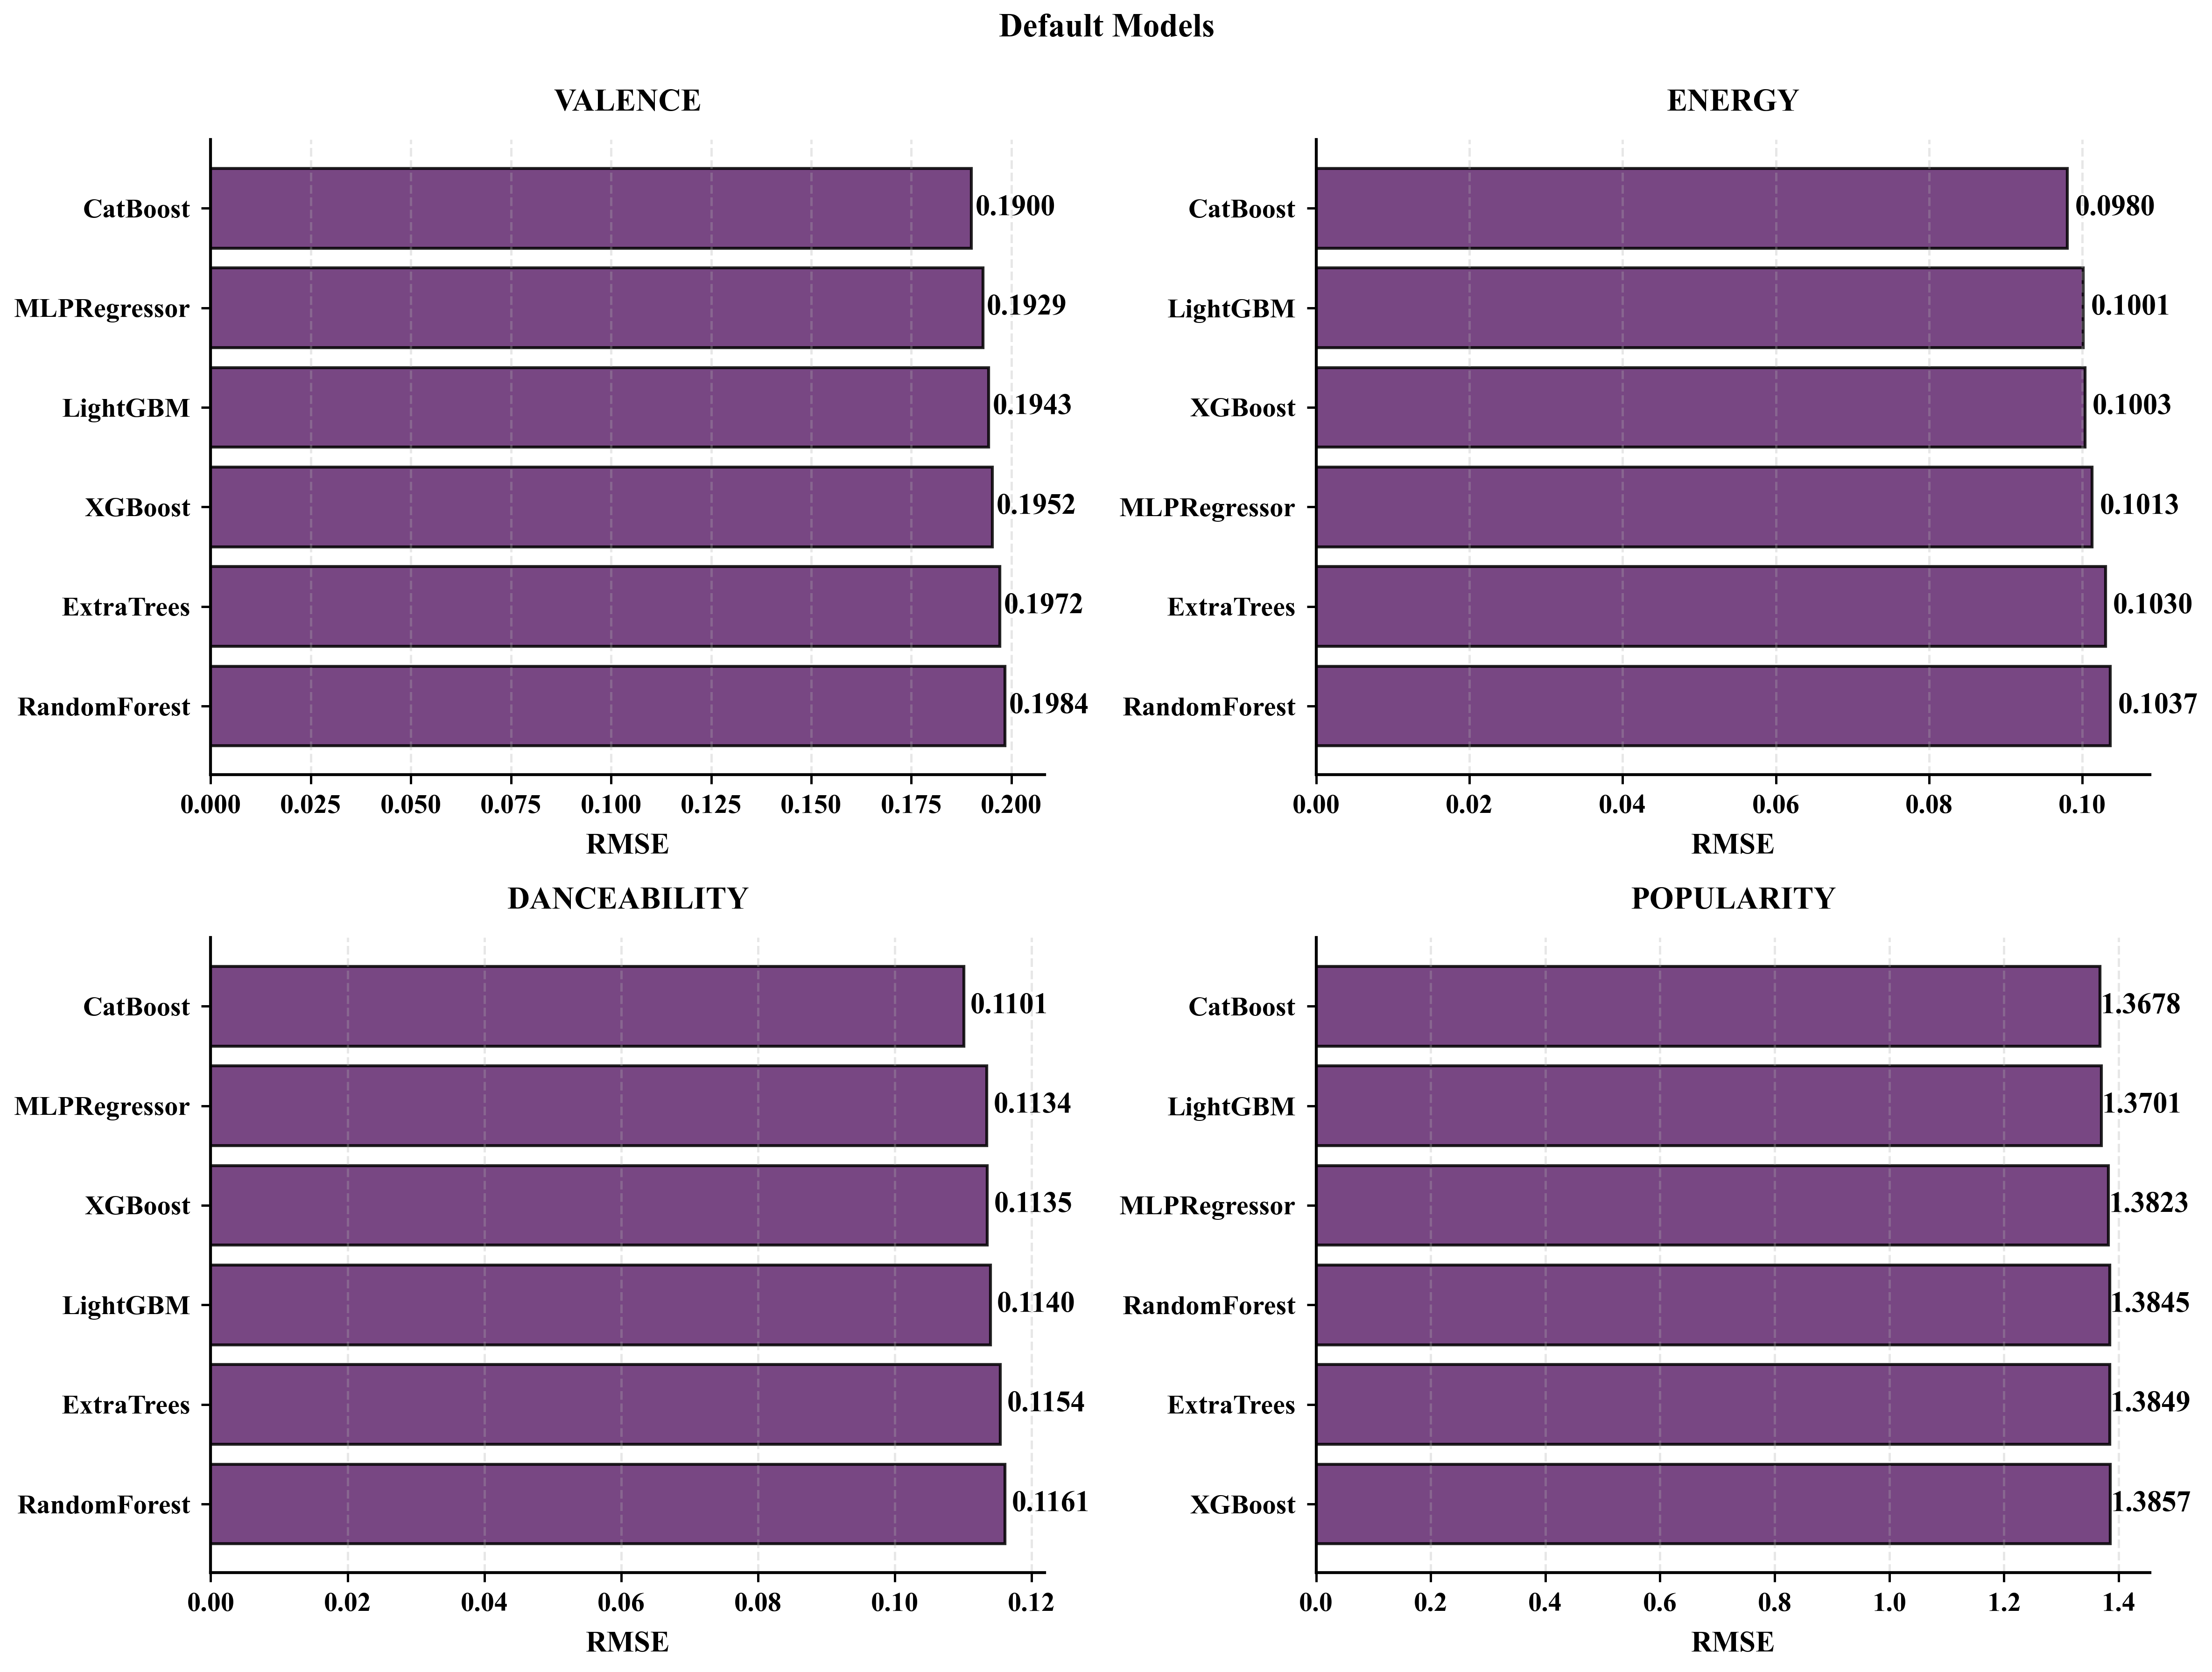

💾 Saved: results/figures/experiment2_default_rmse.png


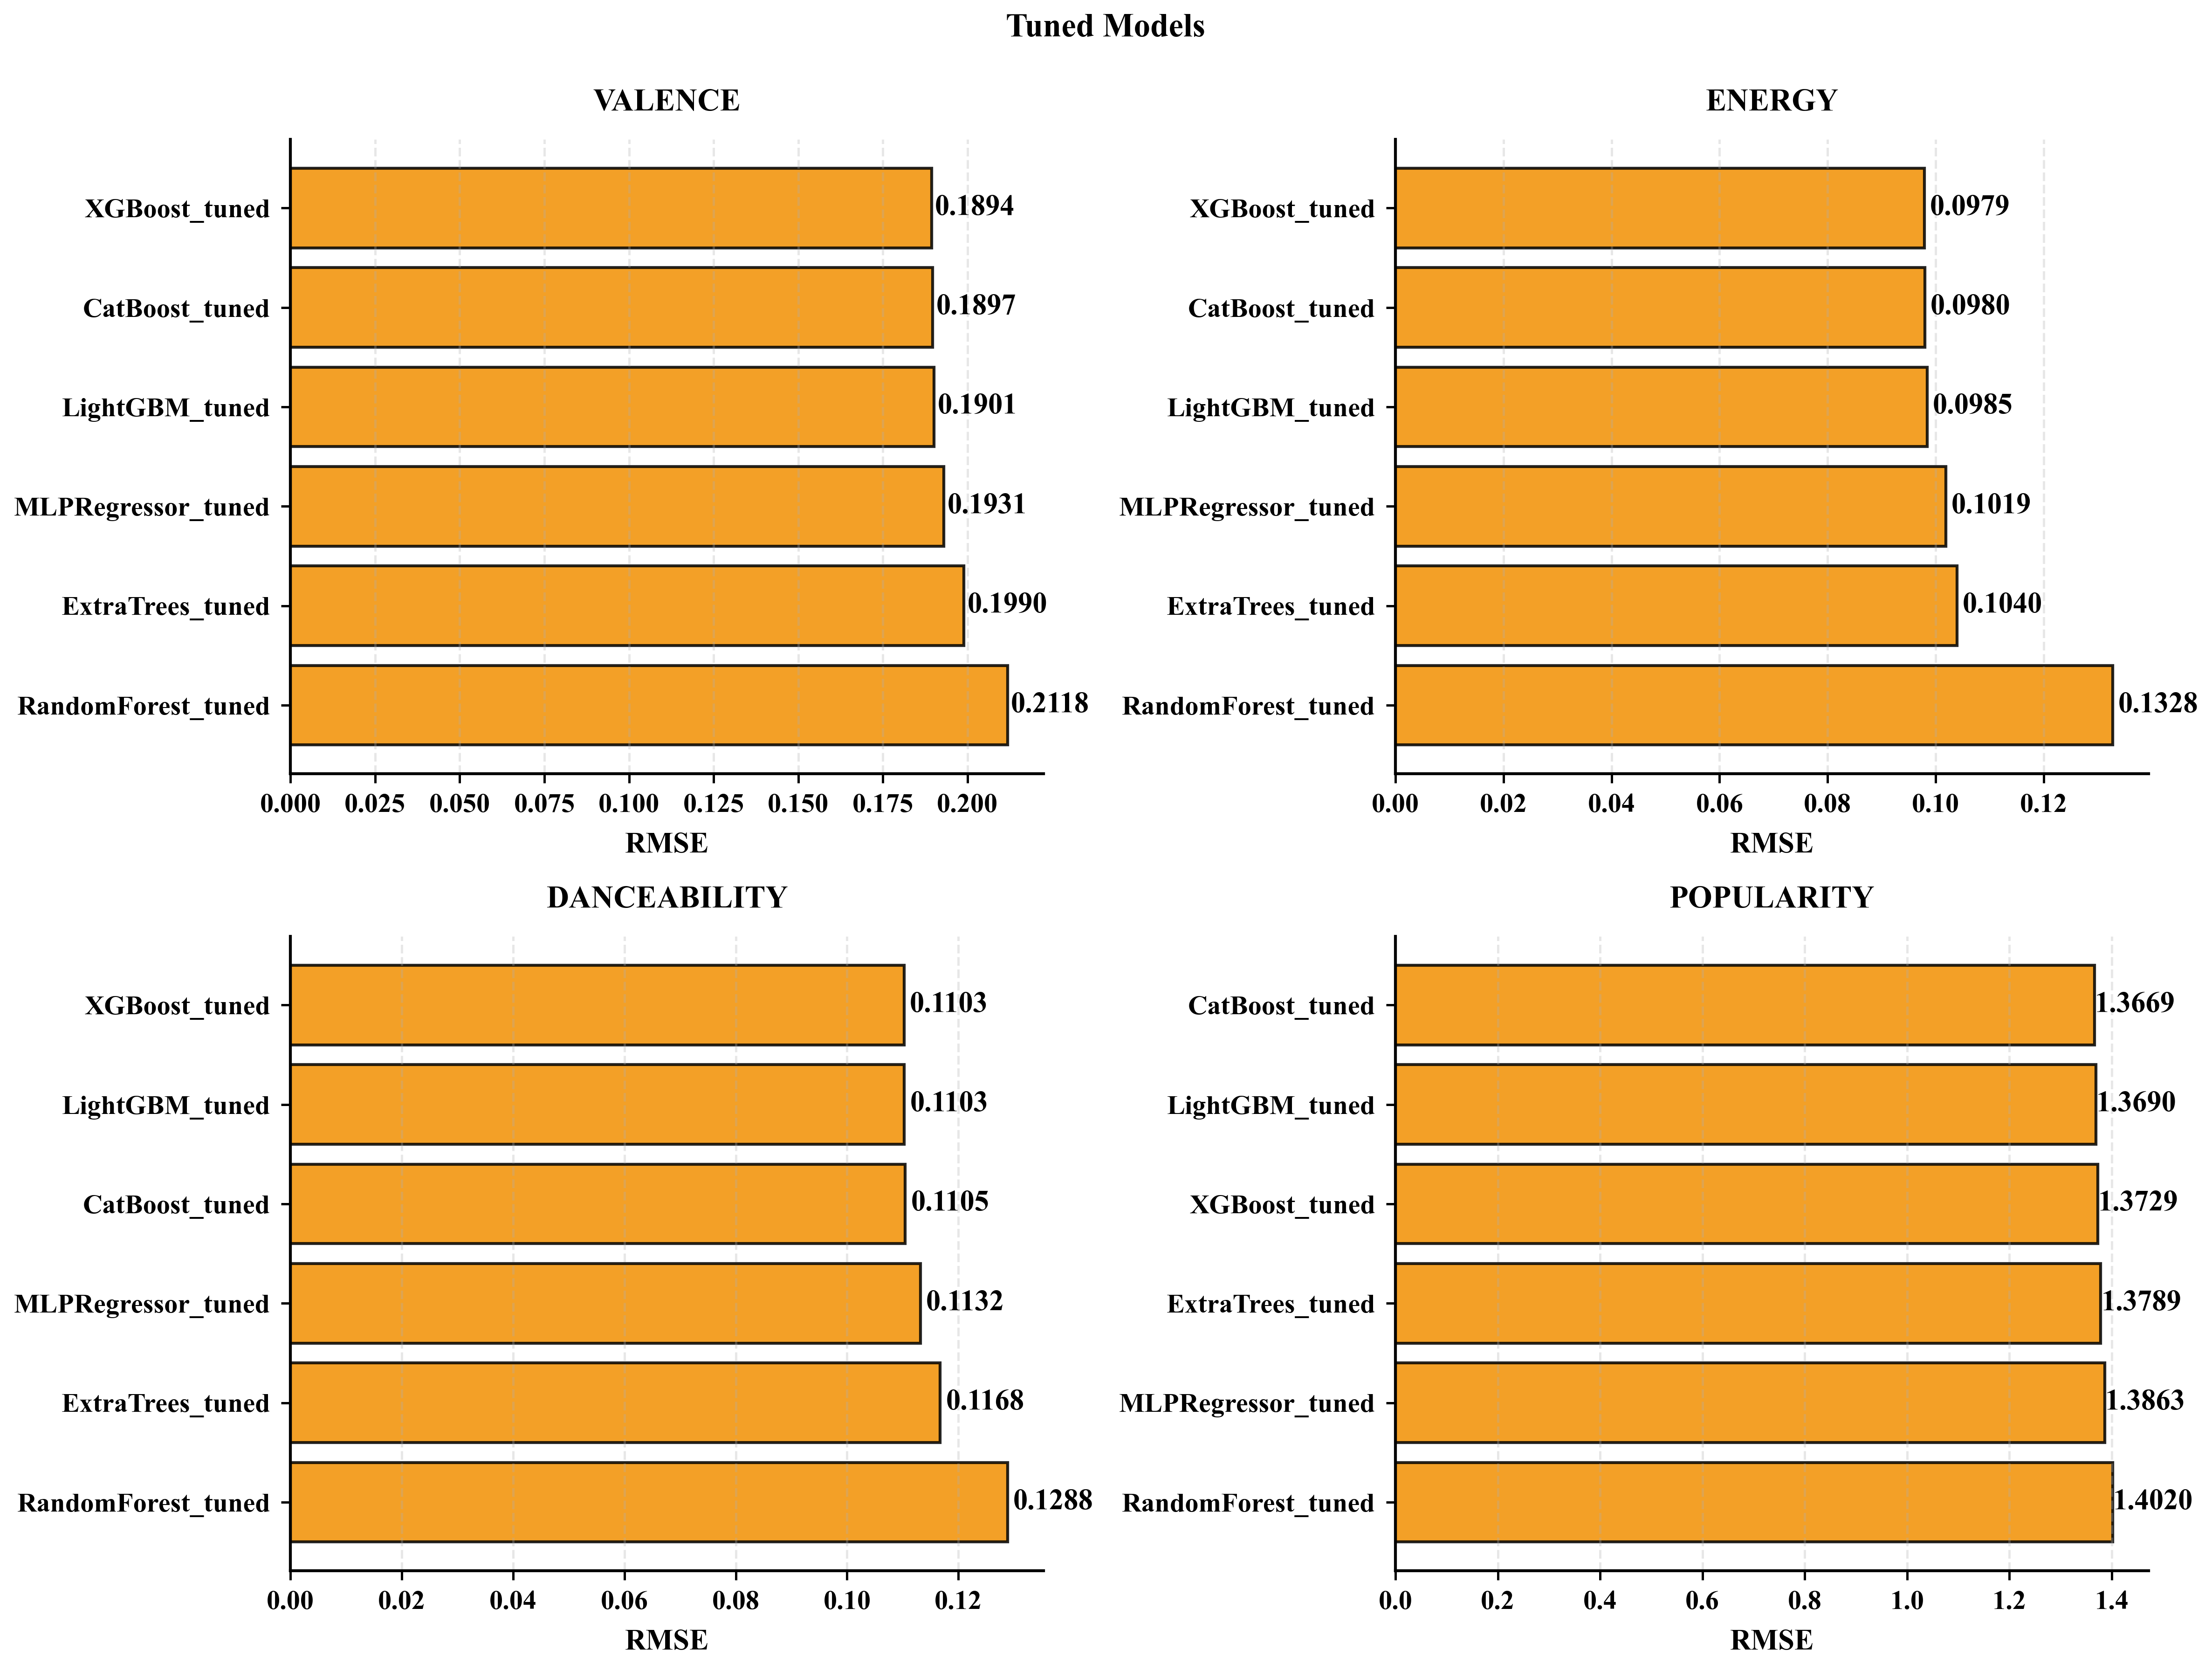

💾 Saved: results/figures/experiment2_tuned_rmse.png


In [22]:
# Create separate RMSE comparison for default and tuned models - Enhanced styling
targets = ['valence', 'energy', 'danceability', 'popularity']

# Default models RMSE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_default[df_default['target'] == target].nsmallest(6, 'rmse')
    
    bars = ax.barh(top_models['model'], top_models['rmse'], color='#60276d', 
                   edgecolor='black', alpha=0.85, linewidth=1.5)
    ax.set_xlabel('RMSE', fontsize=15, fontweight='bold', labelpad=8)
    ax.set_title(f'{target.upper()}', fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', width=1.2, labelsize=12)
    
    # Add value labels
    for bar, val in zip(bars, top_models['rmse']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=15, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=14)

plt.suptitle('Default Models', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_default_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_default_rmse.png")

# Tuned models RMSE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_tuned[df_tuned['target'] == target].nsmallest(6, 'rmse')
    
    bars = ax.barh(top_models['model'], top_models['rmse'], color='#F18F01', 
                   edgecolor='black', alpha=0.85, linewidth=1.5)
    ax.set_xlabel('RMSE', fontsize=15, fontweight='bold', labelpad=8)
    ax.set_title(f'{target.upper()}', fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', width=1.2, labelsize=12)
    
    # Add value labels
    for bar, val in zip(bars, top_models['rmse']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=15, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=14)
plt.suptitle('Tuned Models', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/figures/experiment2_tuned_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_tuned_rmse.png")

---
## 🔬 Default vs Tuned Models Comparison

In [12]:
# Compare default vs tuned versions
tuned_models = df[df['model'].str.contains('_tuned')].copy()
tuned_models['base_model'] = tuned_models['model'].str.replace('_tuned', '')

default_models = df[~df['model'].str.contains('_tuned')].copy()
default_models['base_model'] = default_models['model']

# Merge to compare
comparison = tuned_models.merge(
    default_models[['target', 'base_model', 'r2', 'rmse']], 
    on=['target', 'base_model'], 
    suffixes=('_tuned', '_default')
)
comparison['r2_improvement'] = comparison['r2_tuned'] - comparison['r2_default']
comparison['rmse_improvement'] = comparison['rmse_default'] - comparison['rmse_tuned']  # Positive = better

# Display improvement summary
improvement_summary = comparison.groupby('base_model').agg({
    'r2_improvement': 'mean',
    'rmse_improvement': 'mean'
}).sort_values('r2_improvement', ascending=False)

print("🔧 Tuning Impact (Average across all targets):")
print("="*50)
styled_improvement = improvement_summary.style.format({
    'r2_improvement': '{:+.4f}',
    'rmse_improvement': '{:+.4f}'
}).set_caption(
    '🔧 Tuning Impact: Positive = Improvement'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
])
display(styled_improvement)

🔧 Tuning Impact (Average across all targets):


,r2_improvement,rmse_improvement
base_model,,
XGBoost,+0.0212,+0.0061
LightGBM,+0.0151,+0.0027
CatBoost,+0.0000,+0.0002
MLPRegressor,-0.0016,-0.0011
ExtraTrees,-0.0044,+0.0005
RandomForest,-0.0814,-0.0182


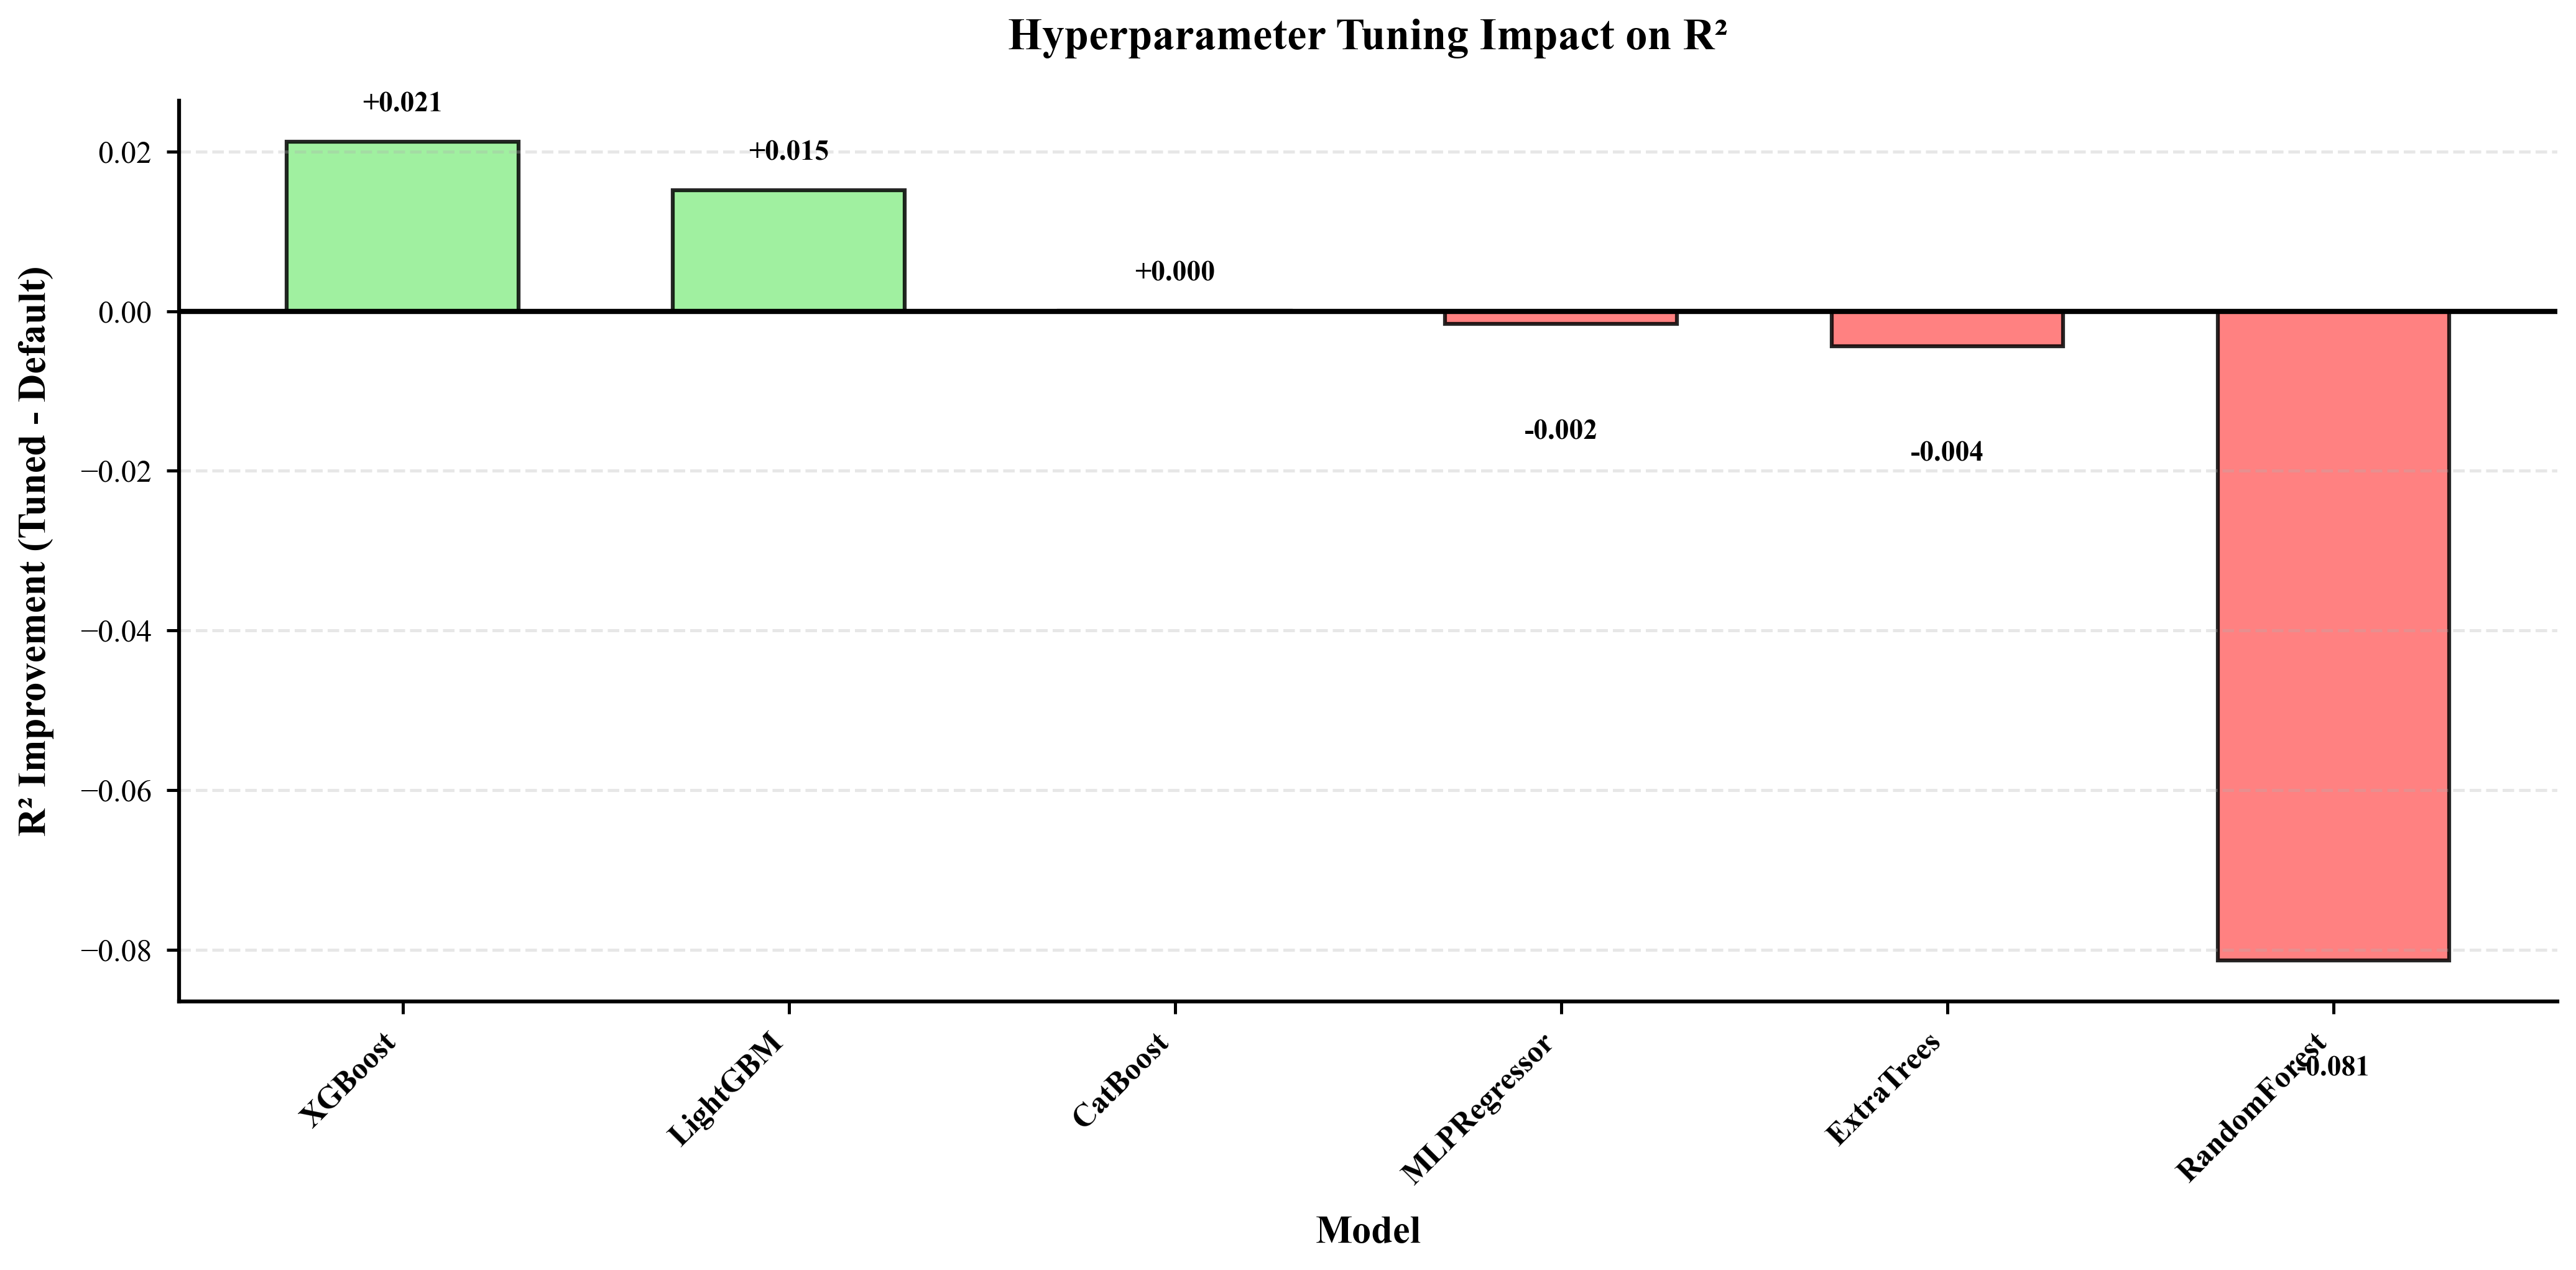

💾 Saved: results/figures/experiment2_tuning_impact_selected.png


In [13]:
# Visualize tuning impact - Enhanced styling
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(improvement_summary))
width = 0.6

bars = ax.bar(x, improvement_summary['r2_improvement'], width, 
              color=['#90EE90' if v > 0 else '#FF6B6B' for v in improvement_summary['r2_improvement']],
              edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Model', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('R² Improvement (Tuned - Default)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Hyperparameter Tuning Impact on R²', 
             fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(improvement_summary.index, rotation=45, ha='right', fontweight='bold', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.2, labelsize=12)

# Add value labels
for bar, val in zip(bars, improvement_summary['r2_improvement']):
    y_pos = val + 0.003 if val >= 0 else val - 0.012
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.3f}', 
            ha='center', va='bottom' if val >= 0 else 'top', 
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/experiment2_tuning_impact_selected.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/experiment2_tuning_impact_selected.png")

---
## 📋 Complete Results Table (All Models, All Targets)

In [14]:
# Create comprehensive tables separated by default and tuned
full_table = df[['target', 'model', 'r2', 'rmse', 'mae', 'explained_variance', 
                 'pred_mean', 'pred_std', 'residual_mean', 'residual_std', 'train_time_seconds']].copy()

# Default models
default_table = full_table[~full_table['model'].str.contains('_tuned')].copy()
default_table = default_table.sort_values(['target', 'r2'], ascending=[True, False])

# Tuned models
tuned_table = full_table[full_table['model'].str.contains('_tuned')].copy()
tuned_table = tuned_table.sort_values(['target', 'r2'], ascending=[True, False])

def color_by_target(val):
    colors = {
        'valence': 'background-color: #E8F4FD',
        'energy': 'background-color: #FDF4E8',
        'danceability': 'background-color: #F4E8FD',
        'popularity': 'background-color: #E8FDF4'
    }
    return colors.get(val, '')

print("="*80)
print("DEFAULT MODELS - COMPLETE RESULTS")
print("="*80)

styled_default = default_table.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}',
    'explained_variance': '{:.4f}',
    'pred_mean': '{:.4f}',
    'pred_std': '{:.4f}',
    'residual_mean': '{:.4f}',
    'residual_std': '{:.4f}',
    'train_time_seconds': '{:.1f}'
}).applymap(color_by_target, subset=['target']).set_caption(
    '📋 Default Models - Complete Results'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('background-color', '#4A90D9'), ('color', 'white')]},
])

display(styled_default)

print("\n" + "="*80)
print("TUNED MODELS - COMPLETE RESULTS")
print("="*80)

styled_tuned = tuned_table.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}',
    'explained_variance': '{:.4f}',
    'pred_mean': '{:.4f}',
    'pred_std': '{:.4f}',
    'residual_mean': '{:.4f}',
    'residual_std': '{:.4f}',
    'train_time_seconds': '{:.1f}'
}).applymap(color_by_target, subset=['target']).set_caption(
    '🔧 Tuned Models - Complete Results'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('background-color', '#F18F01'), ('color', 'white')]},
])

display(styled_tuned)

DEFAULT MODELS - COMPLETE RESULTS


,target,model,r2,rmse,mae,explained_variance,pred_mean,pred_std,residual_mean,residual_std,train_time_seconds
65,danceability,CatBoost,0.5948,0.1101,0.0870,0.5953,0.5298,0.1326,0.0038,0.1100,189.7
73,danceability,MLPRegressor,0.5697,0.1134,0.0894,0.5702,0.5301,0.1330,0.0036,0.1134,1199.3
63,danceability,XGBoost,0.5689,0.1135,0.0897,0.5694,0.5296,0.1335,0.0040,0.1135,97.3
67,danceability,LightGBM,0.5657,0.1140,0.0904,0.5663,0.5294,0.1277,0.0042,0.1139,28.3
59,danceability,ExtraTrees,0.5544,0.1154,0.0918,0.5553,0.5284,0.1185,0.0052,0.1153,1014.0
57,danceability,RandomForest,0.5490,0.1161,0.0923,0.5501,0.5281,0.1226,0.0055,0.1160,4616.3
40,energy,CatBoost,0.8472,0.0980,0.0735,0.8472,0.6502,0.2324,0.0002,0.0980,204.8
42,energy,LightGBM,0.8406,0.1001,0.0752,0.8406,0.6506,0.2307,-0.0002,0.1001,27.7
38,energy,XGBoost,0.8400,0.1003,0.0753,0.8400,0.6502,0.2333,0.0003,0.1003,84.5
48,energy,MLPRegressor,0.8369,0.1013,0.0759,0.8370,0.6526,0.2345,-0.0022,0.1013,1696.2



TUNED MODELS - COMPLETE RESULTS


,target,model,r2,rmse,mae,explained_variance,pred_mean,pred_std,residual_mean,residual_std,train_time_seconds
64,danceability,XGBoost_tuned,0.5933,0.1103,0.0872,0.5939,0.5297,0.1307,0.0039,0.1102,562.7
68,danceability,LightGBM_tuned,0.5932,0.1103,0.0870,0.5937,0.5298,0.1323,0.0038,0.1102,74.9
66,danceability,CatBoost_tuned,0.5920,0.1105,0.0873,0.5925,0.5298,0.1326,0.0038,0.1104,850.3
74,danceability,MLPRegressor_tuned,0.5715,0.1132,0.0893,0.5719,0.5299,0.1330,0.0037,0.1131,290.5
60,danceability,ExtraTrees_tuned,0.5442,0.1168,0.0930,0.5447,0.5296,0.1149,0.0040,0.1167,611.1
58,danceability,RandomForest_tuned,0.4450,0.1288,0.1038,0.4459,0.5285,0.0884,0.0051,0.1287,204.4
39,energy,XGBoost_tuned,0.8475,0.0979,0.0733,0.8475,0.6503,0.2307,0.0001,0.0979,401.7
41,energy,CatBoost_tuned,0.8473,0.0980,0.0733,0.8473,0.6499,0.2327,0.0005,0.0980,809.8
43,energy,LightGBM_tuned,0.8459,0.0985,0.0739,0.8459,0.6503,0.2317,0.0001,0.0985,47.5
49,energy,MLPRegressor_tuned,0.8349,0.1019,0.0770,0.8350,0.6477,0.2317,0.0028,0.1019,726.6


---
## 🎯 Final Recommendations

In [15]:
# Get top 2 models per target for both default and tuned
recommendations = []
targets = ['valence', 'energy', 'danceability', 'popularity']

print("="*80)
print("🎯 FINAL RECOMMENDATIONS")
print("="*80)

for target in targets:
    print(f"\n{target.upper()}:")
    print("-" * 60)
    
    # Top default model
    top_default = df_default[df_default['target'] == target].nlargest(1, 'r2').iloc[0]
    print(f"  Default: {top_default['model']}")
    print(f"    R² = {top_default['r2']:.4f} | RMSE = {top_default['rmse']:.4f} | Time = {top_default['train_time_seconds']:.1f}s")
    
    # Top tuned model
    top_tuned = df_tuned[df_tuned['target'] == target].nlargest(1, 'r2').iloc[0]
    print(f"  Tuned:   {top_tuned['model']}")
    print(f"    R² = {top_tuned['r2']:.4f} | RMSE = {top_tuned['rmse']:.4f} | Time = {top_tuned['train_time_seconds']:.1f}s")
    
    # Improvement
    r2_imp = top_tuned['r2'] - top_default['r2']
    rmse_imp = top_default['rmse'] - top_tuned['rmse']
    print(f"  Improvement: R² {r2_imp:+.4f} | RMSE {rmse_imp:+.4f}")
    
    # Add to recommendations
    rec_default = top_default[['target', 'model', 'r2', 'rmse', 'train_time_seconds']].to_dict()
    rec_default['type'] = 'Default'
    recommendations.append(rec_default)
    
    rec_tuned = top_tuned[['target', 'model', 'r2', 'rmse', 'train_time_seconds']].to_dict()
    rec_tuned['type'] = 'Tuned'
    recommendations.append(rec_tuned)

# Create recommendations dataframe
rec_df = pd.DataFrame(recommendations)
rec_df = rec_df[['target', 'type', 'model', 'r2', 'rmse', 'train_time_seconds']]

print("\n" + "="*80)
print("RECOMMENDATIONS TABLE")
print("="*80)

styled_rec = rec_df.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'train_time_seconds': '{:.1f}s'
}).set_caption('🎯 Final Model Recommendations').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]},
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white')]},
])

display(styled_rec)

🎯 FINAL RECOMMENDATIONS

VALENCE:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.4132 | RMSE = 0.1900 | Time = 158.2s
  Tuned:   XGBoost_tuned
    R² = 0.4169 | RMSE = 0.1894 | Time = 709.6s
  Improvement: R² +0.0037 | RMSE +0.0006

ENERGY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.8472 | RMSE = 0.0980 | Time = 204.8s
  Tuned:   XGBoost_tuned
    R² = 0.8475 | RMSE = 0.0979 | Time = 401.7s
  Improvement: R² +0.0003 | RMSE +0.0001

DANCEABILITY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.5948 | RMSE = 0.1101 | Time = 189.7s
  Tuned:   XGBoost_tuned
    R² = 0.5933 | RMSE = 0.1103 | Time = 562.7s
  Improvement: R² -0.0015 | RMSE -0.0002

POPULARITY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.1394 | RMSE = 1.3678 | Time = 167.1s
  Tuned:   CatBoost_tuned
    R² = 0.1405 | RMSE = 1.3669 | Time = 385.

,target,type,model,r2,rmse,train_time_seconds
0,valence,Default,CatBoost,0.4132,0.1900,158.2s
1,valence,Tuned,XGBoost_tuned,0.4169,0.1894,709.6s
2,energy,Default,CatBoost,0.8472,0.0980,204.8s
3,energy,Tuned,XGBoost_tuned,0.8475,0.0979,401.7s
4,danceability,Default,CatBoost,0.5948,0.1101,189.7s
5,danceability,Tuned,XGBoost_tuned,0.5933,0.1103,562.7s
6,popularity,Default,CatBoost,0.1394,1.3678,167.1s
7,popularity,Tuned,CatBoost_tuned,0.1405,1.3669,385.6s


---
## ✅ Next Steps

Based on Experiment 2 analysis (WITH artist features):

1. **Compare with Experiment 1** - Quantify artist feature contribution
2. **Feature importance analysis** - Where do artist features rank?
3. **Run test evaluation** on selected models (one-time final evaluation)
4. **Document ablation study findings** for thesis